In [61]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pathlib import Path

In [62]:
RUTA = "/home/jovyan/work"

### CARGA Y TIPADO

In [63]:
df = pd.read_csv(RUTA + "/data/data.csv", encoding="utf-8")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria:     {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Dimensiones: 737,691 filas × 11 columnas
Memoria:     288.4 MB


### ESTANDARIZACIÓN DE DATOS

#### GENERO

In [64]:
print(df["genero"].value_counts().to_string())

genero
Hombre        135581
Mujer         133378
Masculino     108963
Femenino      108238
HOMBRE         65873
MUJER          64722
MASCULINO      60945
FEMENINO       59889
No binario        87
Trans             15


In [65]:
MAPA_GENERO = {
    # Masculino — todas las variantes
    "HOMBRE":    "Masculino",
    "Hombre":    "Masculino",
    "MASCULINO": "Masculino",
    "Masculino": "Masculino",
    # Femenino — todas las variantes
    "MUJER":     "Femenino",
    "Mujer":     "Femenino",
    "FEMENINO":  "Femenino",
    "Femenino":  "Femenino",
    # Otros — conservar pero estandarizar
    "No binario": "No Binario",
    "Trans":      "Trans",
}

df["genero"] = df["genero"].str.strip().map(MAPA_GENERO)

# Verificar resultado
print(df["genero"].value_counts().to_string())
print(f"\nSin mapear (NaN): {df['genero'].isna().sum()}")

genero
Masculino     371362
Femenino      366227
No Binario        87
Trans             15

Sin mapear (NaN): 0


### EXTRACCION DE DATOS

In [66]:
df['fecha'] = pd.to_datetime(
    df['anio'].astype(str) + '-' +df['semestre'].astype(str) + '-01'
)

In [67]:
df_modelo = (
    df.groupby(["codigo_institucion", "codigo_programa", "codigo_municipio", "codigo_genero", "fecha"], as_index=False)
    .agg(matriculados=("matriculados", "sum"))
)

# Contar filas por grupo (sin la columna fecha)
conteo_por_grupo = (
    df_modelo.groupby(["codigo_institucion", "codigo_programa", "codigo_municipio", "codigo_genero"])
    .size()
    .reset_index(name="cantidad_registros")
)

grupos_validos = conteo_por_grupo[conteo_por_grupo["cantidad_registros"] > 10]

# Quedarse solo con esos grupos en df_modelo
df_modelo = df_modelo.merge(
    grupos_validos[["codigo_institucion", "codigo_programa", "codigo_municipio", "codigo_genero"]],
    on=["codigo_institucion", "codigo_programa", "codigo_municipio", "codigo_genero"],
    how="inner"
)

### EDA

#### NULOS

In [68]:
print("  Tipos de datos y valores nulos:")
info = pd.DataFrame({
    "dtype":  df_modelo.dtypes,
    "nulos":  df_modelo.isnull().sum(),
    "% nulo": (df_modelo.isnull().mean() * 100).round(2),
})
print(info.to_string())

  Tipos de datos y valores nulos:
                             dtype  nulos  % nulo
codigo_institucion           int64      0     0.0
codigo_programa              int64      0     0.0
codigo_municipio             int64      0     0.0
codigo_genero                int64      0     0.0
fecha               datetime64[us]      0     0.0
matriculados                 int64      0     0.0


#### DUPLICADOS

In [69]:
# Determinamos la cantidad de datos duplicados
print("  Tipos de datos y valores duoplicados:")
info = pd.DataFrame({
    "dtype":  df_modelo.dtypes,
    "duplicados":  df_modelo.duplicated().sum(),
    "% duplicados": (df_modelo.duplicated().mean() * 100).round(2),
})
print(info.to_string())

  Tipos de datos y valores duoplicados:
                             dtype  duplicados  % duplicados
codigo_institucion           int64           0           0.0
codigo_programa              int64           0           0.0
codigo_municipio             int64           0           0.0
codigo_genero                int64           0           0.0
fecha               datetime64[us]           0           0.0
matriculados                 int64           0           0.0


#### MATRICULADOS EN CERO

In [70]:
# Determinar la cantidad de matriculados en cero
ceros = df[df["matriculados"] == 0]
print(f"\nFilas con matriculados = 0: {len(ceros):,} ({len(ceros)/len(df)*100:.1f}%)")


Filas con matriculados = 0: 0 (0.0%)


In [71]:
# PARÁMETROS AJUSTABLES ─────────────────────────────────────────────────────
COLS_GRUPO = ['codigo_programa', 'codigo_municipio', 'codigo_genero']
CRITERIOS = {
    'min_observaciones': 12,   # mínimo 6 años (12 semestres)
    'max_pct_ceros':     0.20, # máximo 20% de ceros
    'min_cv':            0.02, # coeficiente de variación mínimo
    'max_pct_nulos':     0.10, # máximo 10% de nulos
    'min_matriculados':  5,    # valor mínimo razonable por período
}

#### EVOLUCION DE MATRICULAS

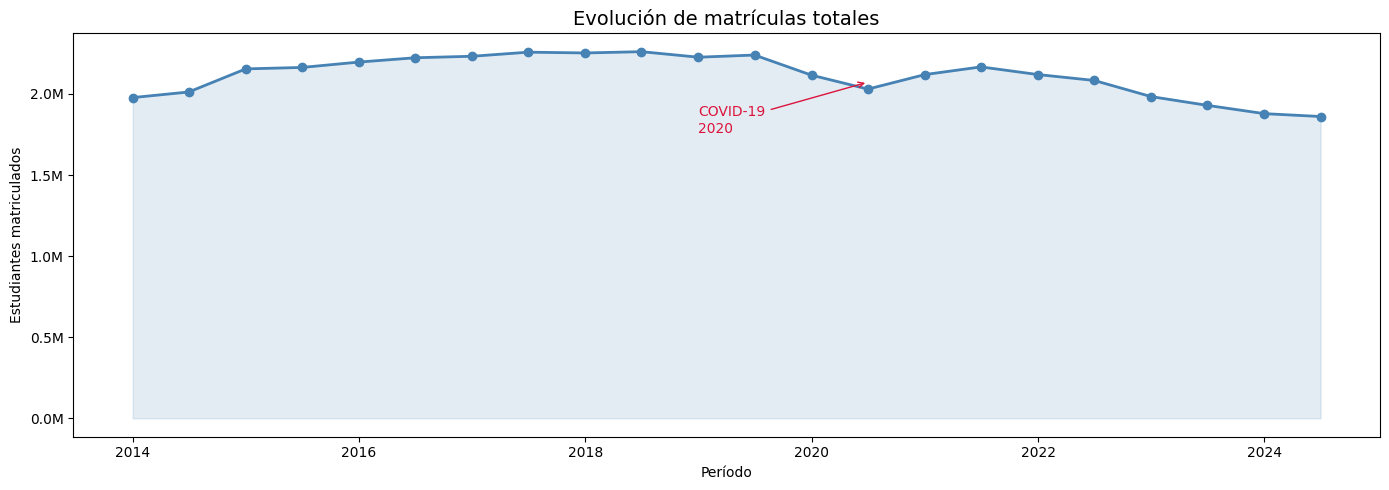

Primer período : 2014-01-01  →  1,977,501
Último período : 2024-07-01  →  1,860,780
Crecimiento acumulado: -5.9%


In [72]:
# Agregar matriculados totales por fecha
total_periodo = df_modelo.groupby('fecha')['matriculados'].sum().reset_index()
total_periodo.columns = ['ds', 'y']

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(total_periodo['ds'], total_periodo['y'], alpha=0.15, color='steelblue')
ax.plot(total_periodo['ds'], total_periodo['y'], marker='o', color='steelblue', lw=2)

# Anotación COVID-19 — solo si hay datos del año 2020
años_disponibles = total_periodo['ds'].dt.year.unique()
if 2020 in años_disponibles:
    covid_y = total_periodo[total_periodo['ds'].dt.year == 2020]['y'].mean()
    ax.annotate(
        'COVID-19\n2020',
        xy=(pd.Timestamp('2020-07-01'), covid_y),
        xytext=(pd.Timestamp('2019-01-01'), covid_y * 0.85),
        arrowprops=dict(arrowstyle='->', color='crimson'),
        fontsize=10, color='crimson'
    )

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Evolución de matrículas totales', fontsize=14, fontweight='normal')
ax.set_xlabel('Período')
ax.set_ylabel('Estudiantes matriculados')
plt.tight_layout()
plt.savefig(RUTA + '/images/eda_serie_total.png', dpi=150, bbox_inches='tight')
plt.show()

# Crecimiento acumulado entre el primer y último período
crecimiento = ((total_periodo['y'].iloc[-1] / total_periodo['y'].iloc[0]) - 1) * 100
print(f"Primer período : {total_periodo['ds'].iloc[0].date()}  →  {int(total_periodo['y'].iloc[0]):,}")
print(f"Último período : {total_periodo['ds'].iloc[-1].date()}  →  {int(total_periodo['y'].iloc[-1]):,}")
print(f"Crecimiento acumulado: {crecimiento:.1f}%")

#### DISTRIBUCIÓN DE MATRÍCULAS POR DIMENSIÓN

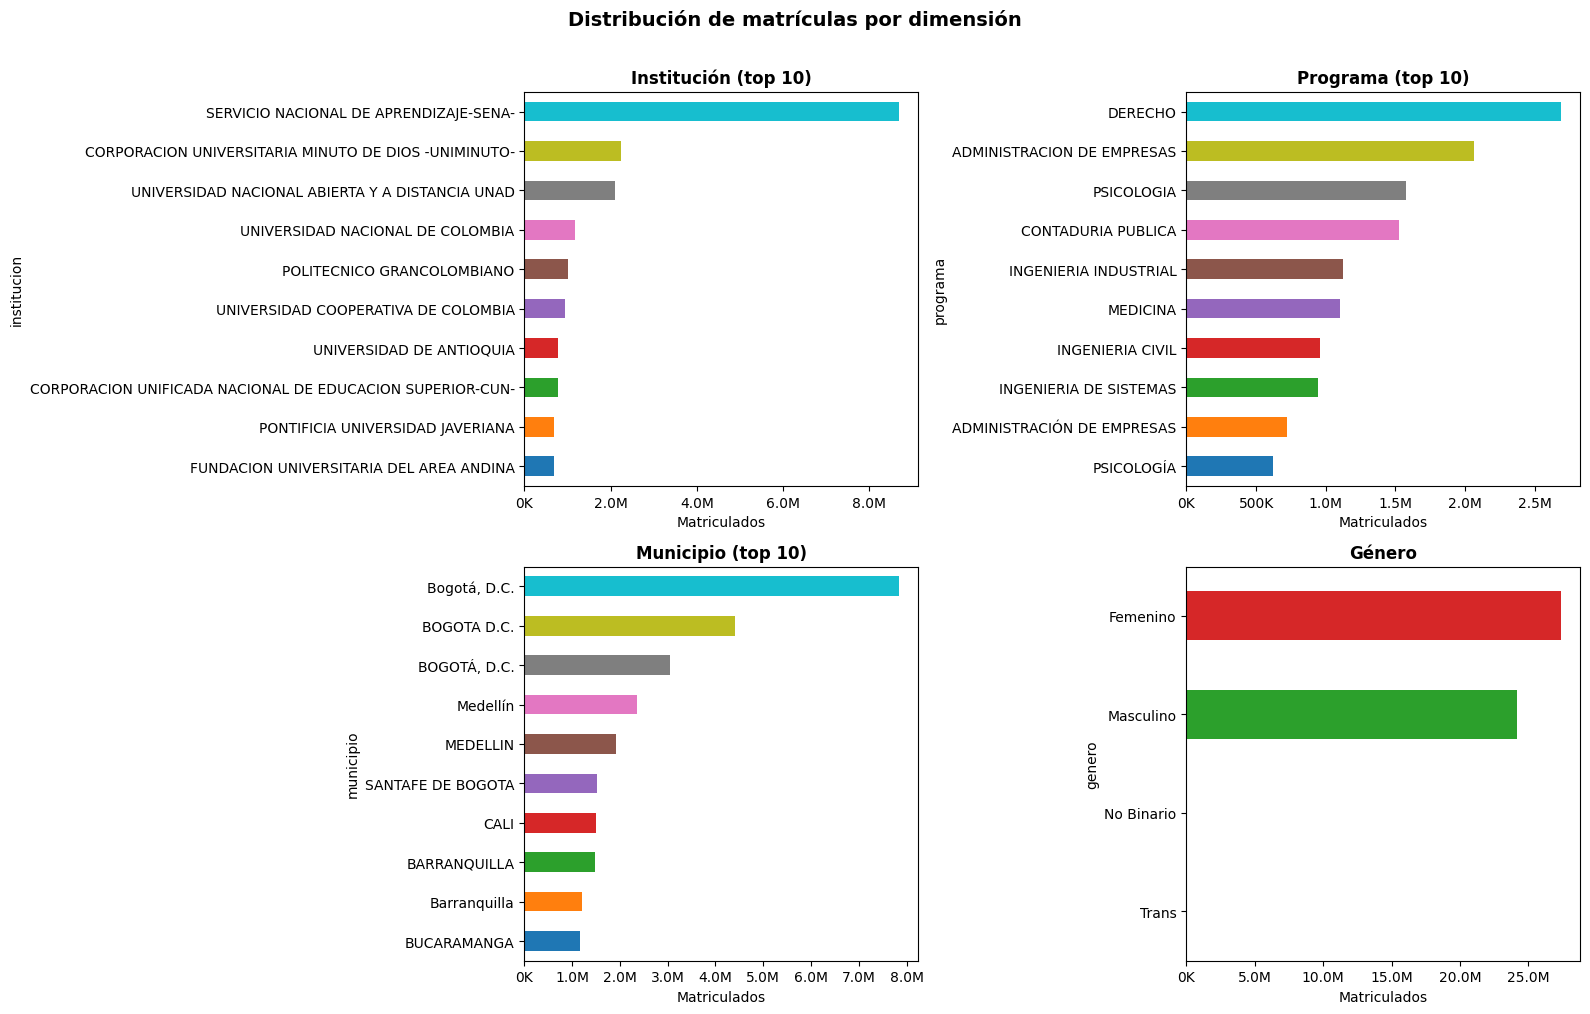

Resumen por dimensión:
  Institución      385 categorías únicas  |  mayor volumen: SERVICIO NACIONAL DE APRENDIZAJE-SENA-
  Programa        11018 categorías únicas  |  mayor volumen: DERECHO
  Municipio       1889 categorías únicas  |  mayor volumen: Bogotá, D.C.
  Género             4 categorías únicas  |  mayor volumen: Femenino


In [73]:
# Dimensiones disponibles en df_modelo
DIMS = [
    ('institucion', 'Institución'),
    ('programa',    'Programa'),
    ('municipio',   'Municipio'),
    ('genero',      'Género'),
]

# Verificar cuáles existen realmente en el dataframe
dims_disponibles = [
    (col, titulo) for col, titulo in DIMS
    if col in df.columns
]

if dims_disponibles:
    n_dims = len(dims_disponibles)
    ncols  = min(n_dims, 2)
    nrows  = (n_dims + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = np.array(axes).flatten()

    for i, (col, titulo) in enumerate(dims_disponibles):
        data = (
            df.groupby(col)['matriculados']
            .sum()
            .sort_values(ascending=True)
        )

        # Limitar a top 10 para dimensiones con muchas categorías
        # (codigo_programa y codigo_municipio pueden tener cientos)
        if len(data) > 10:
            data = data.tail(10)
            subtitulo = f'{titulo} (top 10)'
        else:
            subtitulo = titulo

        data.plot(
            kind='barh',
            ax=axes[i],
            color=sns.color_palette('tab10', len(data))
        )
        axes[i].set_title(subtitulo, fontweight='bold')
        axes[i].set_xlabel('Matriculados')
        axes[i].set_ylabel(col)
        axes[i].xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K')
        )

    # Ocultar subplots sobrantes si n_dims es impar
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        'Distribución de matrículas por dimensión',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(RUTA + '/images/eda_dimensiones.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Resumen numérico por dimensión
    print("Resumen por dimensión:")
    for col, titulo in dims_disponibles:
        n_categorias = df[col].nunique()
        top          = df.groupby(col)['matriculados'].sum().idxmax()
        print(f"  {titulo:<15} {n_categorias:>4} categorías únicas  |  mayor volumen: {top}")

else:
    print("No se encontraron las columnas de dimensión en df_modelo.")
    print(f"Columnas disponibles: {list(df.columns)}")

#### BRECHA DE GÉNERO POR AÑO

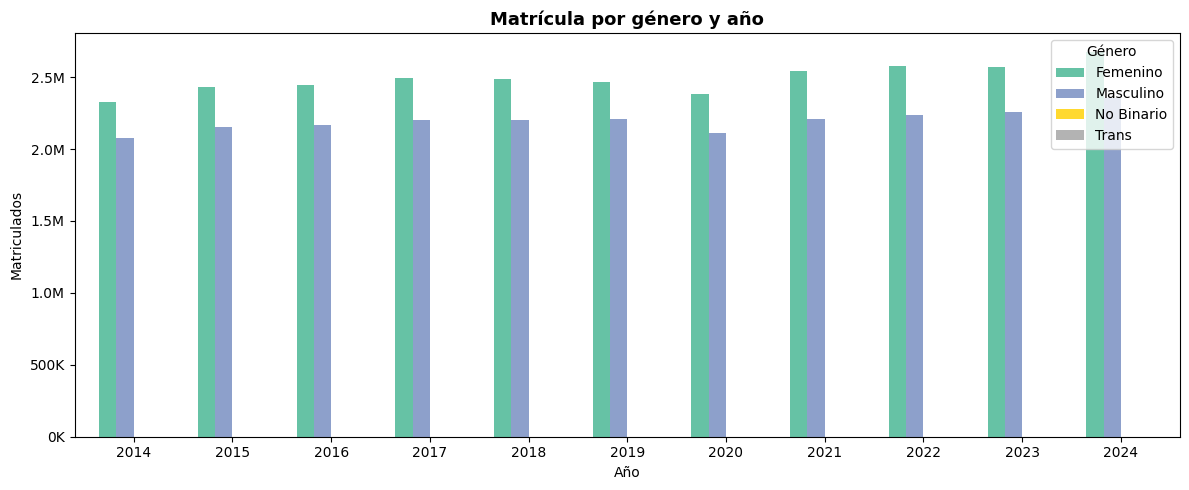


Matrícula total por género:
genero_label
Femenino      27,395,156
Masculino     24,173,581
No Binario           102
Trans                 15
dtype: str


In [74]:
# Extraer año desde fecha y mapear código a etiqueta
df['anio']         = df['fecha'].dt.year
df['genero_label'] = df['genero']

# Verificar que el mapeo cubrió todos los códigos
codigos_sin_mapear = df[df['genero_label'].isna()]['codigo_genero'].unique()
if len(codigos_sin_mapear) > 0:
    print(f"ADVERTENCIA: códigos sin etiqueta → {codigos_sin_mapear}")
    print("Agrega esos códigos al diccionario MAPA_GENERO")

# Agrupar y graficar
genero_año = (
    df.groupby(['anio', 'genero_label'])['matriculados']
    .sum()
    .unstack()
)

fig, ax = plt.subplots(figsize=(12, 5))
genero_año.plot(kind='bar', ax=ax, width=0.7, colormap='Set2')
ax.set_title('Matrícula por género y año', fontweight='bold', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('Matriculados')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'
))
ax.legend(title='Género')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(RUTA + '/images/eda_genero.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen numérico
print("\nMatrícula total por género:")
print(genero_año.sum().apply(lambda x: f"{int(x):,}"))

### EXPORTAR DATA

In [75]:
df_modelo.to_csv(RUTA + "/data/data_historico.csv", index=False, encoding="utf-8")
 
print(f"   data_historico.csv generado")
print(f"   Filas    : {df_modelo.shape[0]:,}")
print(f"   Columnas : {df_modelo.shape[1]}")
print(f"\n   Columnas:")

for col in df_modelo.columns:
    print(f"   - {col}")

   data_historico.csv generado
   Filas    : 553,745
   Columnas : 6

   Columnas:
   - codigo_institucion
   - codigo_programa
   - codigo_municipio
   - codigo_genero
   - fecha
   - matriculados
